In [1]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-colorblind')    

import numpy as np
import datetime
import networkx as nx
import pandas as pd

from utils_graphs import *
from utils_data_vis import *

In [2]:
datasets_folder = "datasets/csvs/"
graphs_folder = "graphs/"
measures_folder = "measures/"
plots_folder = "plots/latex/"

# Horas críticas identificadas en el artículo de Beiró and Gandica et al.
HORA_CRITICA_NAT = "429624"
HORA_CRITICA_9N = "437037"
HORA_CRITICA_CH = "394717"

hour_window_nat = 1
hour_window_9n = 2
hour_window_ch = 2

limites = True

# AUTOSIMILITUD EN LAS REDES

## Redes normales (hashtags como nodos) 

In [3]:
# MAX_UMBRAL es el máximo K_T que se va a usar para generar subgrafos
MAX_UMBRAL = 200

dict_hora_nat_h = get_dict_hora_kt("nat", HORA_CRITICA_NAT, hour_window=hour_window_nat, node_type="hashtag", MAX_UMBRAL=MAX_UMBRAL)
dict_hora_9n_h = get_dict_hora_kt("9n", HORA_CRITICA_9N, hour_window=hour_window_9n, node_type="hashtag", MAX_UMBRAL=MAX_UMBRAL)
dict_hora_ch_h = get_dict_hora_kt("ch", HORA_CRITICA_CH, hour_window=hour_window_ch, node_type="hashtag", MAX_UMBRAL=MAX_UMBRAL)

100%|██████████| 200/200 [00:00<00:00, 1679.20it/s]


In [4]:
limit_kt_nat_h = 35
limit_kt_9n_h = 60
limit_kt_ch_h = 25

critical_kt_nat_h = 30
critical_kt_9n_h = 40
critical_kt_ch_h = 15

arr_kt_plot_nat_h = [0,2,4,8,9,10]
arr_kt_plot_9n_h = [0,10,15,20,25,30,35,40]
arr_kt_plot_ch_h = [0,7,9,11,13,15]



In [5]:
plfit_nat_h, arr_pdf_points_nat_h, arr_ccdf_points_nat_h = calc_degree_distribution(HORA_CRITICA_NAT, "nat/" + str(hour_window_nat) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_nat_h, exp=False, norm=True, read=False)
plfit_9n_h, arr_pdf_points_9n_h, arr_ccdf_points_9n_h = calc_degree_distribution(HORA_CRITICA_9N,  "9n/" + str(hour_window_9n) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_9n_h, exp=False, norm=True, read=False)
plfit_ch_h, arr_pdf_points_ch_h, arr_ccdf_points_ch_h = calc_degree_distribution(HORA_CRITICA_CH,  "ch/" + str(hour_window_ch) + '/', mode="h", measures_folder=measures_folder, arr_kt=arr_kt_plot_ch_h, exp=False, norm=True, read=False)

100%|██████████| 6/6 [00:00<00:00, 313.37it/s]


In [6]:
# Seleccionamos el fichero correspondiente a la manifestación social de la que queremos sacar la red y seleccionamos la hora que queremos estudiar
dict_thres_avg_clust_nat_h, dict_norm_int_deg_nat_h = calc_self_sim(HORA_CRITICA_NAT, MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/')
dict_thres_avg_clust_9n_h, dict_norm_int_deg_9n_h = calc_self_sim(HORA_CRITICA_9N, MAX_UMBRAL, "9n/" + str(hour_window_9n) + '/')
dict_thres_avg_clust_ch_h, dict_norm_int_deg_ch_h = calc_self_sim(HORA_CRITICA_CH, MAX_UMBRAL, "ch/" + str(hour_window_ch) + '/')

100%|██████████| 200/200 [00:00<00:00, 289.33it/s]


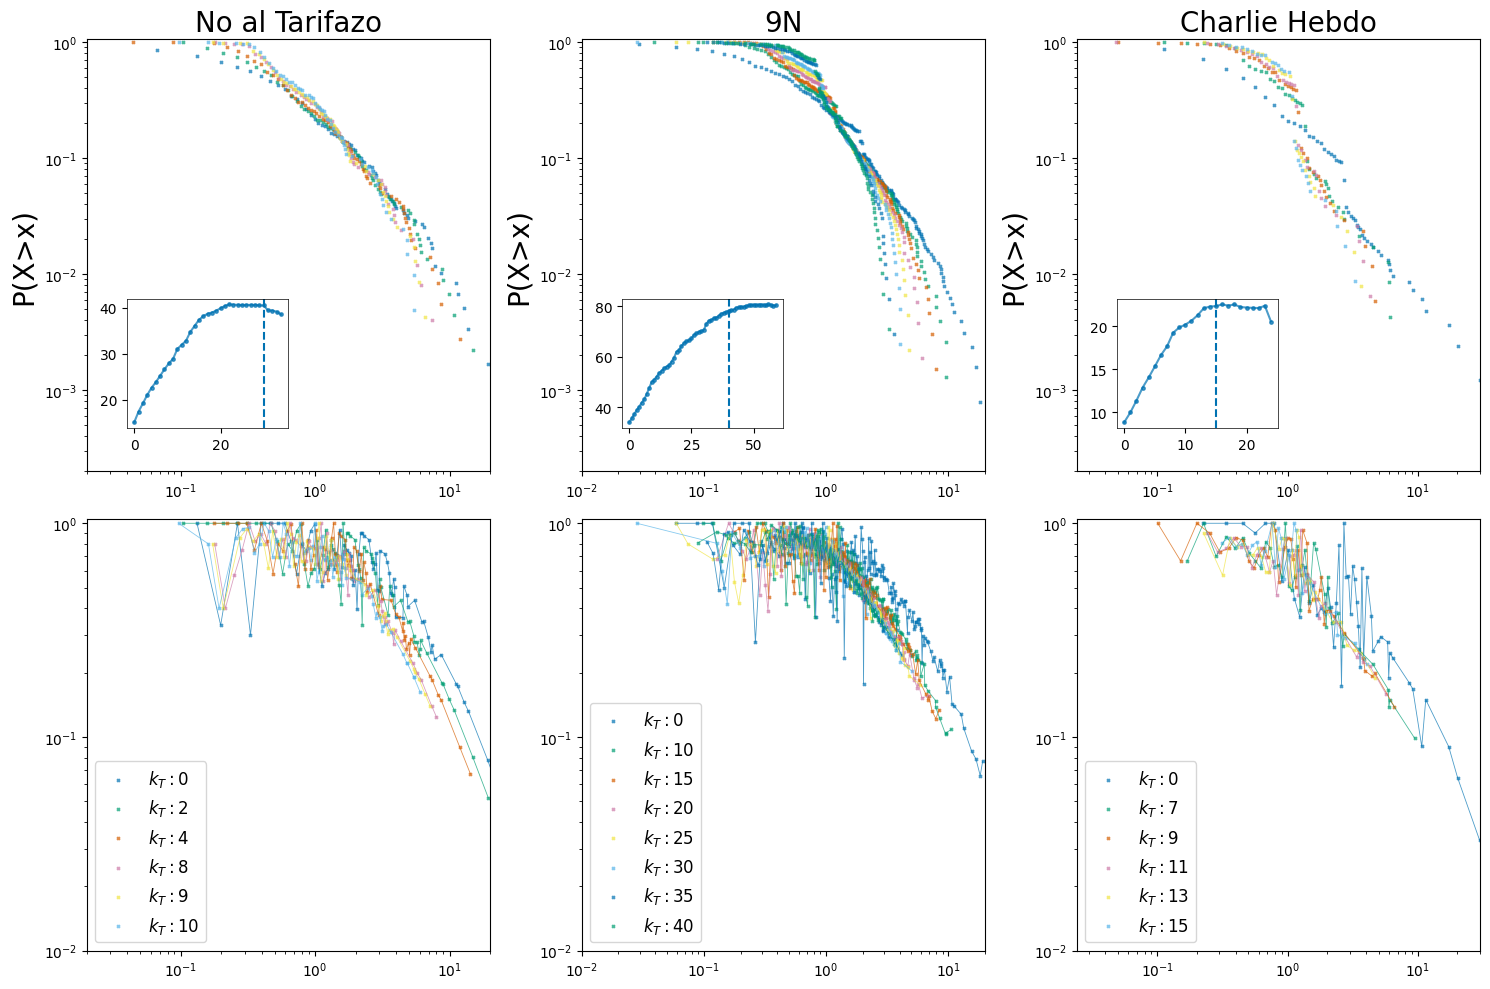

In [7]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(2, 3)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")
fig.set_size_inches(15,10)

xlim_nat_h = (0.02, 20)
xlim_9n_h = (0.01, 20)
xlim_ch_h = (0.024, 30)

plot_pdf(axs[0], arr_ccdf_points_nat_h, arr_kt_plot_nat_h, title="No al Tarifazo", ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_nat_h)
ax0_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax0_inset, dict_hora_nat_h, limit_kt_nat_h, axvline=critical_kt_nat_h)

plot_pdf(axs[1], arr_ccdf_points_9n_h, arr_kt_plot_9n_h, title="9N", ylim=(0.0002, 1.05), xlim=xlim_9n_h)
ax1_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax1_inset, dict_hora_9n_h, limit_kt_9n_h, axvline=critical_kt_9n_h)

plot_pdf(axs[2], arr_ccdf_points_ch_h, arr_kt_plot_ch_h, title="Charlie Hebdo", ylim=(0.0002, 1.05), xlim=xlim_ch_h)
ax2_inset = axs[2].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax2_inset, dict_hora_ch_h, limit_kt_ch_h, axvline=critical_kt_ch_h)


plot_clust_ss(axs[3], arr_kt_plot_nat_h, dict_norm_int_deg_nat_h, xlim=xlim_nat_h, ylim=(0.01, 1.05))
plot_clust_ss(axs[4], arr_kt_plot_9n_h, dict_norm_int_deg_9n_h, xlim=xlim_9n_h, ylim=(0.01, 1.05))
plot_clust_ss(axs[5], arr_kt_plot_ch_h, dict_norm_int_deg_ch_h, xlim=xlim_ch_h, ylim=(0.01, 1.05))

plt.tight_layout()
plt.savefig(plots_folder + "CCDF_degree_self_sim_paper_hashtag.png")
plt.show()

## Grafos Filtrados

### Creación de los grafos filtrados

In [8]:
# Threshold empleado para cada manifestacion
umbral_nat = 3
umbral_9n = 5
umbral_ch = 3

# CREACIÓN DE LOS GRAFOS FILTRADOS
write_filtered_graph("nat", HORA_CRITICA_NAT, umbral_nat, graphs_folder, hour_window_nat)
write_filtered_graph("9n", HORA_CRITICA_9N, umbral_9n, graphs_folder, hour_window_9n)
write_filtered_graph("ch", HORA_CRITICA_CH, umbral_ch, graphs_folder, hour_window_ch)

Grafo nat:429624  (umbral 3) reducido a 19.16 % en nodos y  16.85 % en aristas.
Grafo 9n:437037  (umbral 5) reducido a 12.58 % en nodos y  7.1 % en aristas.
Grafo ch:394717  (umbral 3) reducido a 13.31 % en nodos y  7.4 % en aristas.


In [9]:
# MAX_UMBRAL es el máximo K_T que se va a usar para generar subgrafos
MAX_UMBRAL = 200
dict_hora_nat_f = get_dict_hora_kt("nat", HORA_CRITICA_NAT, hour_window=hour_window_nat, node_type="filtered", MAX_UMBRAL=MAX_UMBRAL, umbral_filt=umbral_nat)
dict_hora_9n_f = get_dict_hora_kt("9n", HORA_CRITICA_9N, hour_window=hour_window_9n, node_type="filtered", MAX_UMBRAL=MAX_UMBRAL, umbral_filt=umbral_9n)
dict_hora_ch_f = get_dict_hora_kt("ch", HORA_CRITICA_CH, hour_window=hour_window_ch, node_type="filtered", MAX_UMBRAL=MAX_UMBRAL, umbral_filt=umbral_ch)

 19%|█▉        | 38/200 [00:00<00:00, 11956.76it/s]


### Autosimilitud de redes filtradas y Resultados en otras ventanas temporales diferentes a la crítica

In [10]:
limit_kt_nat_f = 35
limit_kt_9n_f = 60
limit_kt_ch_f = 30

critical_kt_nat_f = 10
critical_kt_9n_f = 18
critical_kt_ch_f = 5

arr_kt_plot_nat_f = [0,2,4,6,8,10]
arr_kt_plot_9n_f = [0,3,6,9,12,15,18]
arr_kt_plot_ch_f = [0,1,2,3,4,5]


In [11]:
plfit_nat_f, arr_pdf_points_nat_f, arr_ccdf_points_nat_f = calc_degree_distribution(HORA_CRITICA_NAT, "nat/" + str(hour_window_nat) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_nat_f, thresh_filt=umbral_nat, norm=True, read=False)
plfit_9n_f, arr_pdf_points_9n_f, arr_ccdf_points_9n_f = calc_degree_distribution(HORA_CRITICA_9N, "9n/" + str(hour_window_9n) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_9n_f, thresh_filt=umbral_9n, norm=True, read=False)
plfit_ch_f, arr_pdf_points_ch_f, arr_ccdf_points_ch_f = calc_degree_distribution(HORA_CRITICA_CH, "ch/" + str(hour_window_ch) + '/', mode="f", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_ch_f, thresh_filt=umbral_ch, norm=True, read=False)

100%|██████████| 6/6 [00:00<00:00, 1017.95it/s]


Calculating best minimal value for power law fit


100%|██████████| 7/7 [00:00<00:00, 545.04it/s]

Calculating best minimal value for power law fit



100%|██████████| 6/6 [00:00<00:00, 3502.55it/s]

Calculating best minimal value for power law fit


In [12]:
# MAX_UMBRAL es el máximo K_T que vamos a usar para generar subgrafos
MAX_UMBRAL = 500
# Seleccionamos el fichero correspondiente a la manifestación social de la que queremos sacar la red y seleccionamos la hora que queremos estudiar
dict_thres_avg_clust_nat_f, dict_norm_int_deg_nat_f = calc_self_sim(HORA_CRITICA_NAT, MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/', mode="f", thresh_filter=umbral_nat)
dict_thres_avg_clust_9n_f, dict_norm_int_deg_9n_f = calc_self_sim(HORA_CRITICA_9N, MAX_UMBRAL, "9n/" + str(hour_window_9n) + '/', mode="f", thresh_filter=umbral_9n)
dict_thres_avg_clust_ch_f, dict_norm_int_deg_ch_f = calc_self_sim(HORA_CRITICA_CH, MAX_UMBRAL, "ch/" + str(hour_window_ch) + '/', mode="f", thresh_filter=umbral_ch)

  0%|          | 0/500 [00:00<?, ?it/s]

  8%|▊         | 38/500 [00:00<00:00, 1769.49it/s]


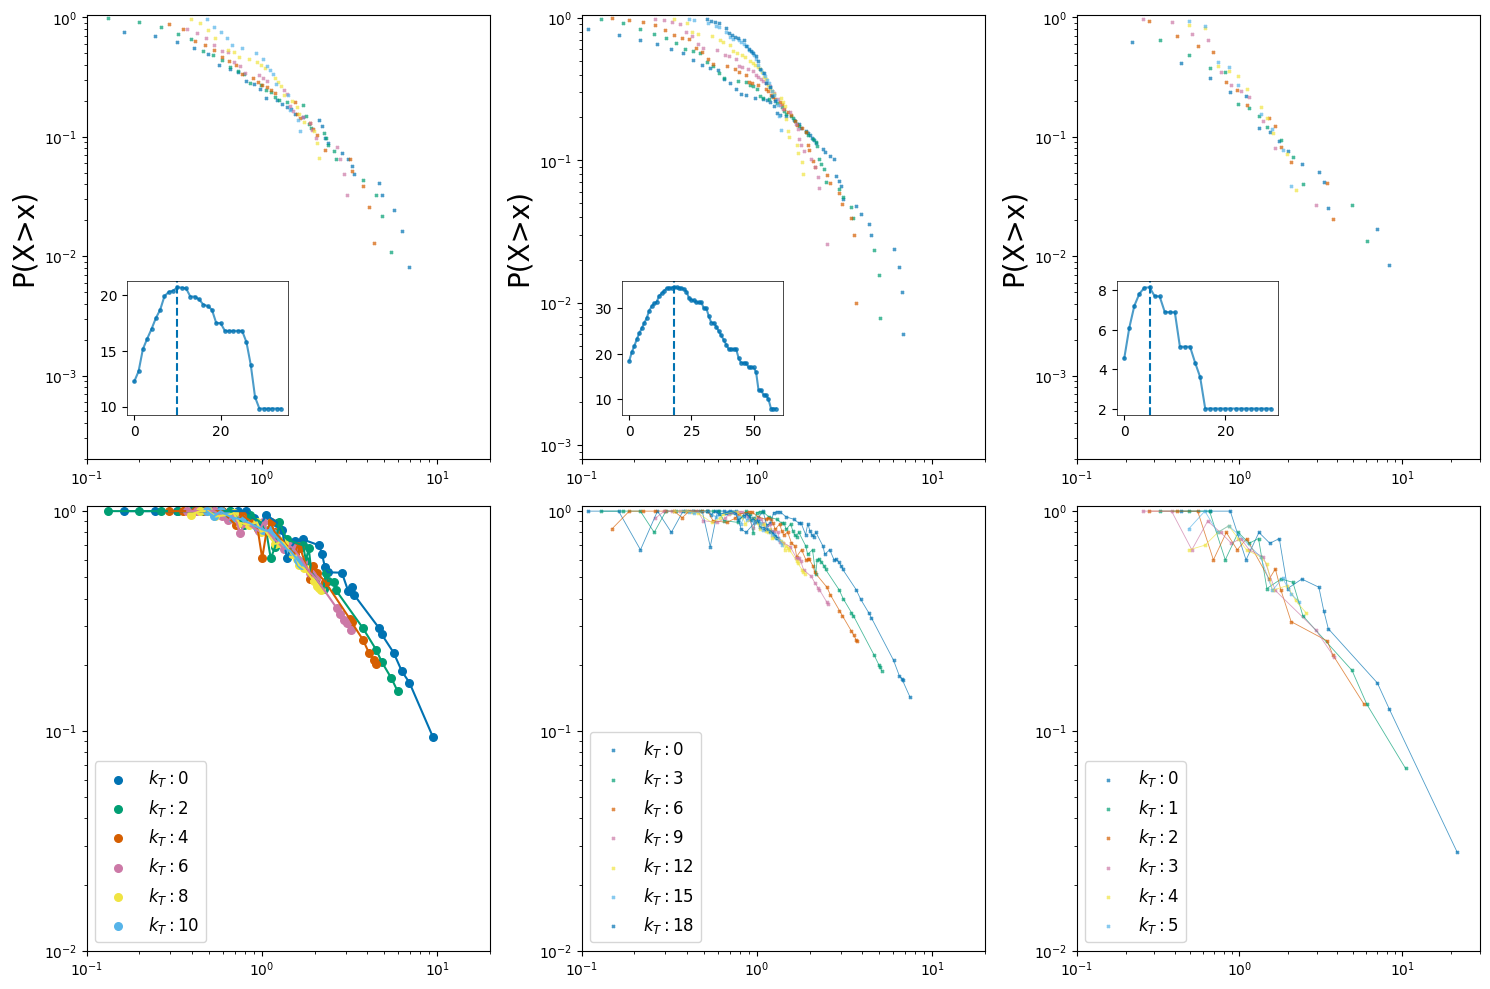

In [13]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(2, 3)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")
fig.set_size_inches(15,10)

xlim_nat_f = (0.1, 20)
xlim_9n_f = (0.1, 20)
xlim_ch_f = (0.1, 30)

plot_pdf(axs[0], arr_ccdf_points_nat_f, arr_kt_plot_nat_f, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_nat_f)
ax6_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax6_inset, dict_hora_nat_f, limit_kt_nat_f, axvline=critical_kt_nat_f)

plot_pdf(axs[1], arr_ccdf_points_9n_f, arr_kt_plot_9n_f, ylim=(0.0008, 1.05), xlim=xlim_9n_f)
ax7_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax7_inset, dict_hora_9n_f, limit_kt_9n_f, axvline=critical_kt_9n_f)

plot_pdf(axs[2], arr_ccdf_points_ch_f, arr_kt_plot_ch_f, ylim=(0.0002, 1.05), xlim=xlim_ch_f)
ax8_inset = axs[2].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax8_inset, dict_hora_ch_f, limit_kt_ch_f, axvline=critical_kt_ch_f)


plot_clust_ss(axs[3], arr_kt_plot_nat_f, dict_norm_int_deg_nat_f, xlim=xlim_nat_f, ylim=(0.01, 1.05), loc="lower left", linewidth=1.5, s=30, marker="o", alpha=1)
plot_clust_ss(axs[4], arr_kt_plot_9n_f, dict_norm_int_deg_9n_f, xlim=xlim_9n_f, ylim=(0.01, 1.05))
plot_clust_ss(axs[5], arr_kt_plot_ch_f, dict_norm_int_deg_ch_f, xlim=xlim_ch_f, ylim=(0.01, 1.05))


plt.tight_layout()
plt.savefig(plots_folder + "CCDF_degree_self_sim_paper_filtered.png")
plt.show()

## Grafos otras horas NO filtradas nat

In [14]:
otras_horas_nat = ["429552", "429576", "429600", "429624", "429648", "429672", "429696", "429636"]

limit_kt_nat_o = 60
arr_kt_plot_nat_o = [0,2,4,6,8,10]


In [15]:
arr_dicts_avg_clust_nat_o = []
arr_dicts_norm_int_deg_nat_o = []
arr_ccdfs_points_nat_o = []
arr_dicts_hora_nat_o = []
arr_dicts_thres_avg_clust_nat_o = []
for hora in otras_horas_nat:

	dict_thres_avg_clust_nat_o, dict_norm_int_deg_nat_o = calc_self_sim(hora, MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/', mode="h")
	plfit_nat_o, arr_pdf_points_nat_o, arr_ccdf_points_nat_o = calc_degree_distribution(hora, "nat/" + str(hour_window_nat) + '/', mode="h", arr_kt=arr_kt_plot_nat_o,read=False, exp=False, norm=True)
	dict_hora_nat_o = get_dict_hora_kt("nat", hora, hour_window=hour_window_nat, node_type="hashtag", MAX_UMBRAL=MAX_UMBRAL)

	arr_dicts_avg_clust_nat_o.append(dict_thres_avg_clust_nat_o)
	arr_dicts_norm_int_deg_nat_o.append(dict_norm_int_deg_nat_o)
	arr_ccdfs_points_nat_o.append(arr_ccdf_points_nat_o)
	arr_dicts_hora_nat_o.append(dict_hora_nat_o)

 19%|█▉        | 97/500 [00:00<00:00, 741.03it/s]


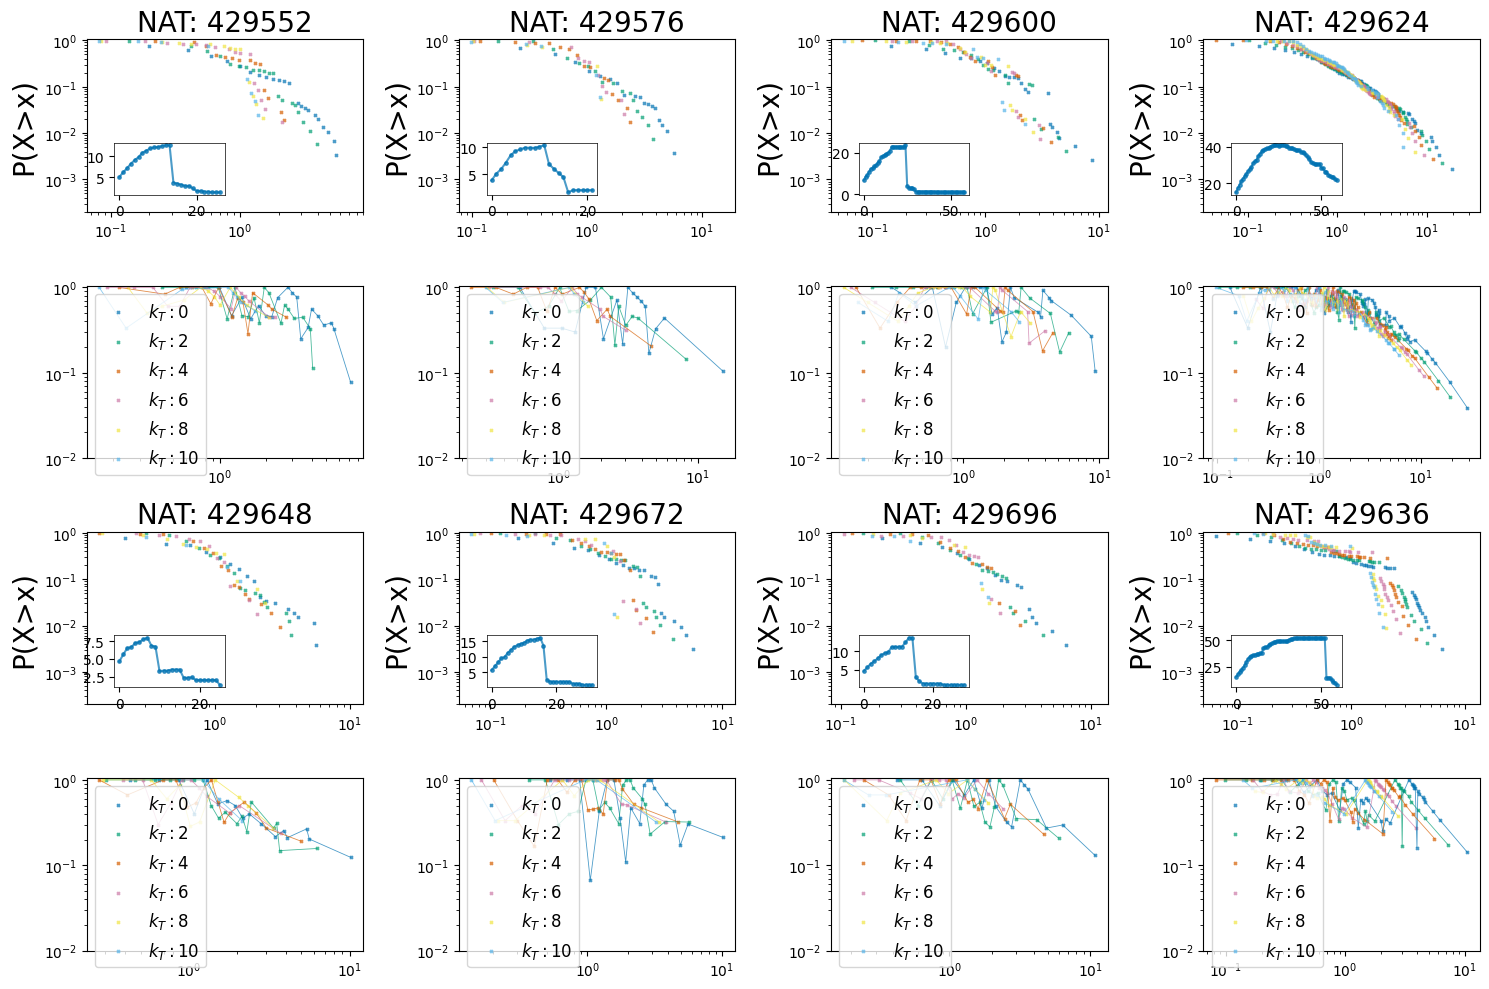

In [16]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(4, 4)
fig.set_size_inches(15,10)

xlim_nat_o = (0.1, 20)
for i, rax in enumerate(axs[::2]):
	index = i*2
	for j, ax in enumerate(rax):
		plot_pdf(axs[index][j], arr_ccdfs_points_nat_o[i*len(rax)+j], arr_kt_plot_nat_o, ylabel="P(X>x)", ylim=(0.0002, 1.05),  title=f"NAT: {otras_horas_nat[i*len(rax)+j]}")
		ax_inset = axs[index][j].inset_axes([0.1, 0.1, 0.4, 0.3])
		plot_avg_deg(ax_inset, arr_dicts_hora_nat_o[i*len(rax)+j], limit_kt_nat_o)
		plot_clust_ss(axs[index+1][j], arr_kt_plot_nat_o, arr_dicts_norm_int_deg_nat_o[i*len(rax)+j], ylim=(0.01, 1.05))

plt.tight_layout()
plt.savefig(plots_folder + "CCDF_degree_self_sim_otras_horas.png")
plt.show()

He probado a filtrarlos, pero en la mayoría de casos, se tratan de grafos tan pequeños que no hay valores para plotear

## Disparity filter with multiple confidence levels

### Redes originales

In [17]:
def convertir_file(hora, filtered=False, umbral=None):
	if not filtered:
		G = nx.read_gexf(f"graphs/nodes_hashtag/nat/1/{hora}.gexf")
		nombre_output = f"disparity_filter/puntos/{hora}.csv"
	else:
		G = nx.read_gexf(f"graphs/nodes_filtered/{umbral}/nat/1/{hora}.gexf")
		nombre_output = f"disparity_filter/puntos/{hora}_filt.csv"
	print(G.number_of_nodes(), G.number_of_edges(), nombre_output)
	with open(nombre_output, "w") as f:
		arr_edges = ""
		for orig, dst, we in G.edges(data=True):
			if "weight" not in G[orig][dst].keys():
				print(orig, dst)
			peso = int(G[orig][dst]["weight"])
			arr_edges = arr_edges + f"{orig},{dst},{peso} \n"
		f.write(arr_edges)
	

In [18]:
arr_kt_plot_nat_d = [0,1,2,4,6,8,10]
horas = ["429552", "429576", "429600", "429624", "429648", "429672", "429696", "429636"]
horas = ["429624"]
for hora in tqdm(horas):
	convertir_file(hora)
	filename_input = f"disparity_filter/puntos/{hora}.csv"
	filename_output = f"disparity_filter/puntos/{hora}_conf_all"
	backbone_confidence(filename_input, filename_output + '.csv')

  0%|          | 0/1 [00:00<?, ?it/s]

642 4470 disparity_filter/puntos/429624.csv


100%|██████████| 1/1 [00:00<00:00,  1.15it/s]


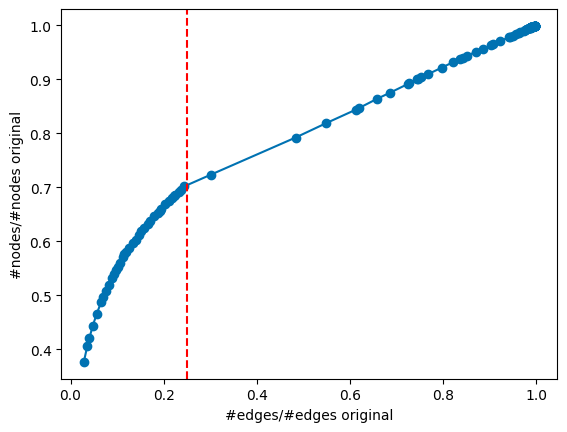

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos desde archivo
datos = np.loadtxt("disparity_filter/puntos/429624_conf_all.csv")

x = datos[:, 3]  
y = datos[:, 1]  

plt.plot(x, y, marker='o')
plt.axvline(x=0.25, color='red', linestyle='--')
plt.xlabel('#edges/#edges original')
plt.ylabel('#nodes/#nodes original')
plt.show()


In [20]:
arr_kt_plot_nat_d = [0,1,2,4,6,8,10]
horas = ["429624"]
for hora in tqdm(horas):
	convertir_file(hora)
	filename_input = f"disparity_filter/puntos/{hora}.csv"
	filename_output = f"disparity_filter/puntos/{hora}_conf"
	backbone(filename_input, filename_output + '25.csv', wconfidence=0.25)


	G = nx.Graph()  # Usa nx.DiGraph() si necesitas que sea dirigido
	with open(f"disparity_filter/puntos/{hora}_conf25.csv", "r") as f:
		for line in f:
			source, target, weight = line.strip().split()
			G.add_edge(int(source), int(target), weight=float(weight))

	nx.write_gexf(G, f"graphs/nodes_disparity/nat/1/{hora}.gexf")


	dict_hora_nat_d = get_dict_hora_kt("nat", hora, hour_window=hour_window_nat, node_type="disparity", MAX_UMBRAL=200)

	plfit_nat_d, arr_pdf_points_nat_d, arr_ccdf_points_nat_d = calc_degree_distribution(hora, "nat/" + str(hour_window_nat) + '/', mode="d", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_nat_d, norm=True)

	dict_thres_avg_clust_nat_h_d, dict_norm_int_deg_nat_h_d = calc_self_sim(hora, 200, "nat/" + str(hour_window_nat) + '/', mode="d")

  0%|          | 0/1 [00:00<?, ?it/s]

642 4470 disparity_filter/puntos/429624.csv
fraction of weight in backbone= 0.9956405097250167 disparity_filter/puntos/429624_conf25.csv


100%|██████████| 7/7 [00:00<00:00, 44018.18it/s]


Calculating best minimal value for power law fit


100%|██████████| 1/1 [00:01<00:00,  1.93s/it]


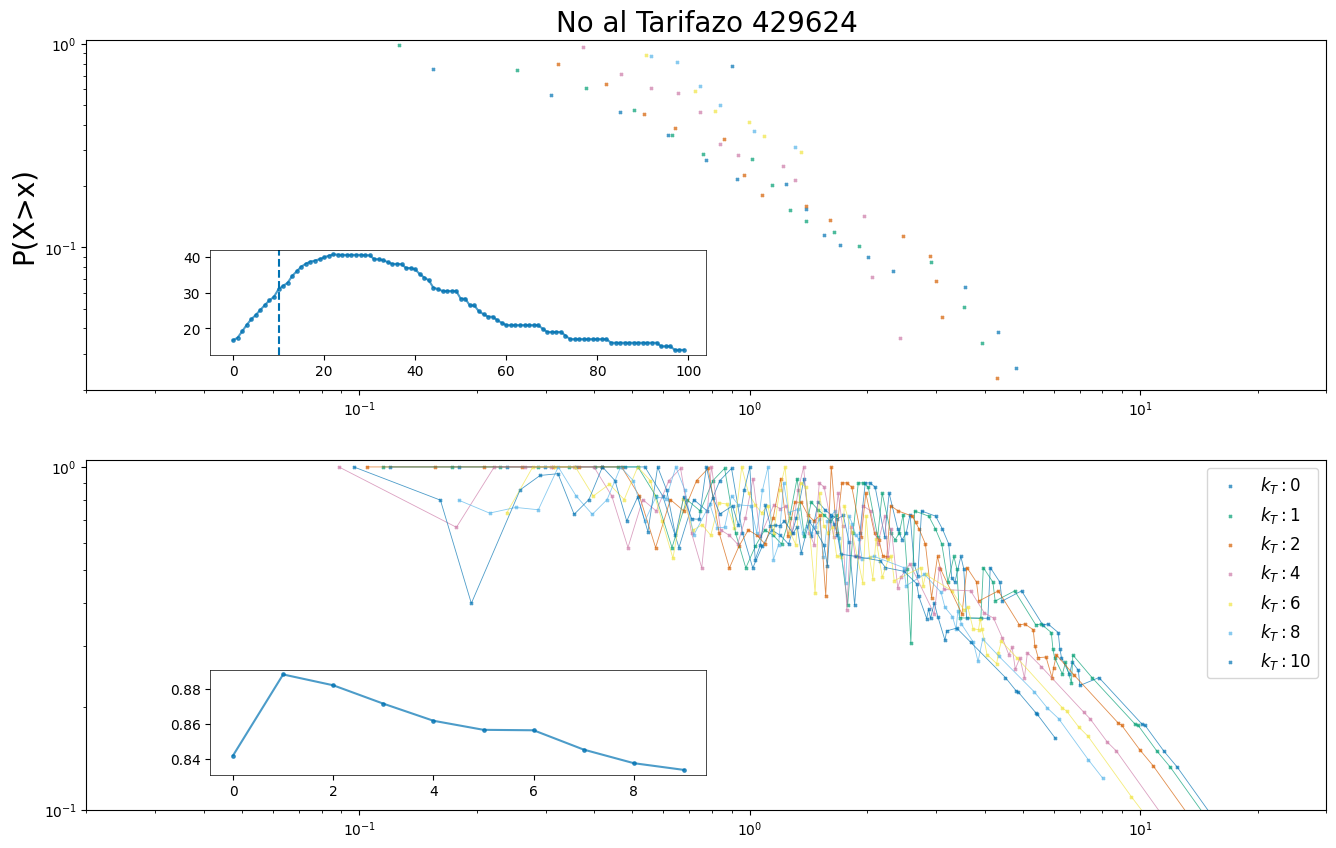

In [21]:

plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(2, 1)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")
fig.set_size_inches(16,10)

plot_pdf(axs[0], arr_ccdf_points_nat_d, arr_kt_plot_nat_d, title=f"No al Tarifazo {horas[0]}", ylabel="P(X>x)", ylim=(0.02, 1.05), xlim = (0.02, 30))
ax0_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax0_inset, dict_hora_nat_d, 100, axvline=10)


plot_clust_ss(axs[1], arr_kt_plot_nat_d, dict_norm_int_deg_nat_h_d, xlim=(0.02, 30), ylim=(0.1, 1.05), legend=True)
ax3_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax3_inset, dict_thres_avg_clust_nat_h_d, 10, dot_size=6)

plt.savefig(plots_folder + "self_sim_disparity.png")
plt.show()

### Redes filtradas

In [22]:
arr_kt_plot_nat_d = [0,1,2,4,6,8,10]
horas = ["429624"]
for hora in tqdm(horas):
	convertir_file(hora, filtered=True, umbral=umbral_nat)
	filename_input = f"disparity_filter/puntos/{hora}_filt.csv"
	filename_output = f"disparity_filter/puntos/{hora}_filt_conf_all"
	backbone_confidence(filename_input, filename_output + '.csv')

100%|██████████| 1/1 [00:00<00:00,  6.02it/s]

123 753 disparity_filter/puntos/429624_filt.csv


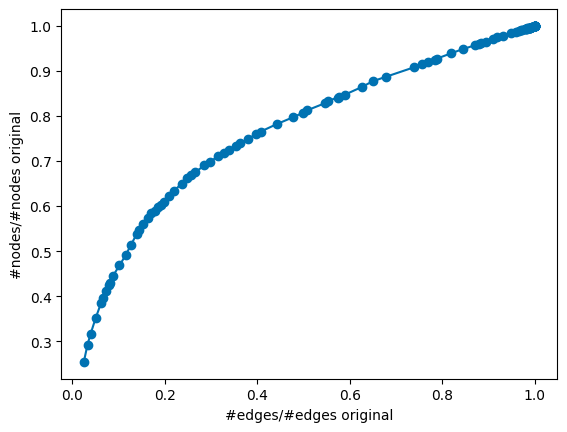

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos desde archivo
datos_f_d = np.loadtxt("disparity_filter/puntos/429624_filt_conf_all.csv")

x = datos_f_d[:, 3]  
y = datos_f_d[:, 1]  

plt.plot(x, y, marker='o')
#plt.axvline(x=0.8, color='red', linestyle='--')
plt.xlabel('#edges/#edges original')
plt.ylabel('#nodes/#nodes original')
plt.show()


In [24]:
arr_kt_plot_nat_f_d = [0,1,2,4,6,8,10]
horas = ["429624"]
for hora in tqdm(horas):
	convertir_file(hora)
	filename_input = f"disparity_filter/puntos/{hora}_filt.csv"
	filename_output = f"disparity_filter/puntos/{hora}_filt_conf"
	backbone(filename_input, filename_output + '25.csv', wconfidence=0.25)


	G = nx.Graph()  # Usa nx.DiGraph() si necesitas que sea dirigido
	with open(f"disparity_filter/puntos/{hora}_filt_conf25.csv", "r") as f:
		for line in f:
			source, target, weight = line.strip().split()
			G.add_edge(int(source), int(target), weight=float(weight))

	nx.write_gexf(G, f"graphs/nodes_disparity/nat/1/{hora}_filt.gexf")

"""	dict_hora_nat_f_d = get_dict_hora_kt("nat", hora, hour_window=hour_window_nat, node_type="disparity", MAX_UMBRAL=200)

	plfit_nat_f_d, arr_pdf_points_nat_f_d, arr_ccdf_points_nat_f_d = calc_degree_distribution(hora, "nat/" + str(hour_window_nat) + '/', mode="d", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_nat_f_d, norm=True)

	dict_thres_avg_clust_nat_f_d, dict_norm_int_deg_nat_f_d = calc_self_sim(hora, 200, "nat/" + str(hour_window_nat) + '/', mode="d")"""
#TBD Adaptar estas funciones (si precisa y tiene sentido para poder emplear el filtrado por disparidad-->Re enrutar adecuadamente el path)


100%|██████████| 1/1 [00:00<00:00, 10.86it/s]

642 4470 disparity_filter/puntos/429624.csv
fraction of weight in backbone= 0.9949396652393928 disparity_filter/puntos/429624_filt_conf25.csv


'\tdict_hora_nat_f_d = get_dict_hora_kt("nat", hora, hour_window=hour_window_nat, node_type="disparity", MAX_UMBRAL=200)\n\n\tplfit_nat_f_d, arr_pdf_points_nat_f_d, arr_ccdf_points_nat_f_d = calc_degree_distribution(hora, "nat/" + str(hour_window_nat) + \'/\', mode="d", graphs_folder=graphs_folder, measures_folder=measures_folder, exp=True, arr_kt=arr_kt_plot_nat_f_d, norm=True)\n\n\tdict_thres_avg_clust_nat_f_d, dict_norm_int_deg_nat_f_d = calc_self_sim(hora, 200, "nat/" + str(hour_window_nat) + \'/\', mode="d")'

In [25]:
"""
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(2, 1)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")
fig.set_size_inches(16,10)

plot_pdf(axs[0], arr_ccdf_points_nat_f_d, arr_kt_plot_nat_f_d, title=f"No al Tarifazo {horas[0]}", ylabel="P(X>x)", ylim=(0.02, 1.05), xlim = (0.02, 30))
ax0_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax0_inset, dict_hora_nat_f_d, 100, axvline=10)


plot_clust_ss(axs[1], arr_kt_plot_nat_f_d, dict_norm_int_deg_nat_f_d, xlim=(0.02, 30), ylim=(0.1, 1.05), legend=True)
ax3_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax3_inset, dict_thres_avg_clust_nat_f_d, 10, dot_size=6)

plt.savefig(plots_folder + "self_sim_disparity_filt.png")
plt.show()"""

'\nplt.style.use(\'seaborn-v0_8-colorblind\')    \n\nfig, axs = plt.subplots(2, 1)\naxs = axs.flat\nfor ax in axs:  \n\tax.set_facecolor("white")\nfig.set_size_inches(16,10)\n\nplot_pdf(axs[0], arr_ccdf_points_nat_f_d, arr_kt_plot_nat_f_d, title=f"No al Tarifazo {horas[0]}", ylabel="P(X>x)", ylim=(0.02, 1.05), xlim = (0.02, 30))\nax0_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])\nplot_avg_deg(ax0_inset, dict_hora_nat_f_d, 100, axvline=10)\n\n\nplot_clust_ss(axs[1], arr_kt_plot_nat_f_d, dict_norm_int_deg_nat_f_d, xlim=(0.02, 30), ylim=(0.1, 1.05), legend=True)\nax3_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])\nplot_avg_deg(ax3_inset, dict_thres_avg_clust_nat_f_d, 10, dot_size=6)\n\nplt.savefig(plots_folder + "self_sim_disparity_filt.png")\nplt.show()'

## Exponential binning

### Redes originales

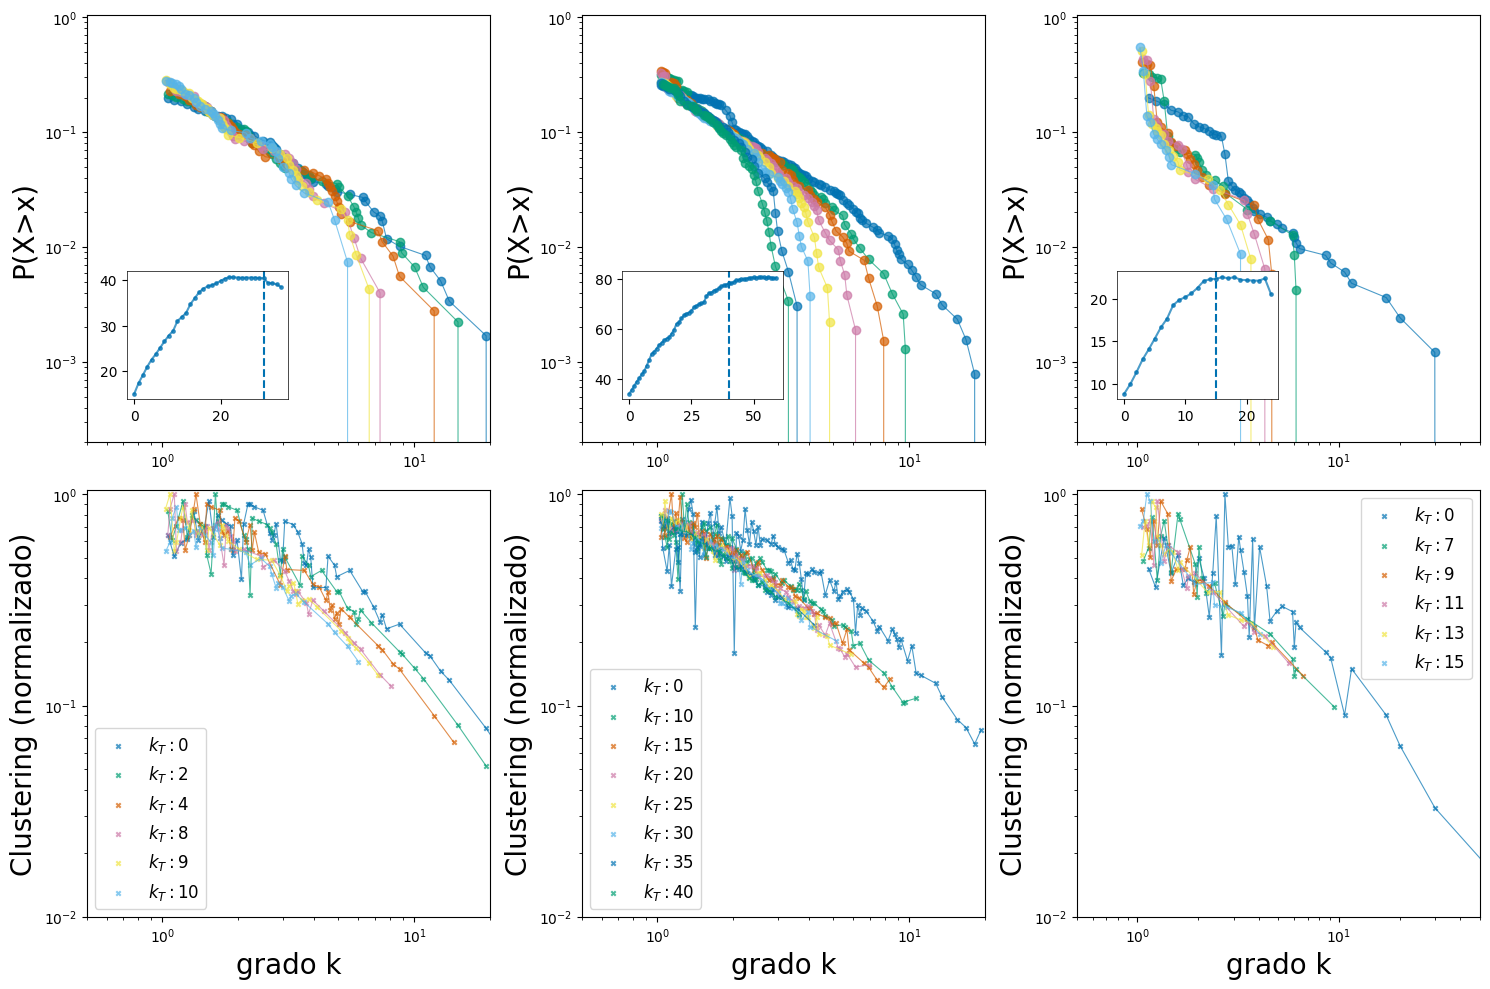

In [26]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(2, 3)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")
fig.set_size_inches(15,10)

xlim_nat_h_e = (0.5, 20)
xlim_9n_h_e = (0.5, 20)
xlim_ch_h_e = (0.5, 50)

plot_pdf_expbin(axs[0], arr_ccdf_points_nat_h, arr_kt_plot_nat_h,
                aa=1.02, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_nat_h_e,
                marker="o", alpha=0.7, dot_size=6, line=True, normalize=False)
ax0_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax0_inset, dict_hora_nat_h, limit_kt_nat_h, axvline=critical_kt_nat_h)

plot_pdf_expbin(axs[1], arr_ccdf_points_9n_h, arr_kt_plot_9n_h,
                aa=1.02, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_9n_h_e,
                marker="o", alpha=0.7, dot_size=6, line=True, normalize=False)
ax1_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax1_inset, dict_hora_9n_h, limit_kt_9n_h, axvline=critical_kt_9n_h)

plot_pdf_expbin(axs[2], arr_ccdf_points_ch_h, arr_kt_plot_ch_h,
                aa=1.02, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_ch_h_e,
                marker="o", alpha=0.7, dot_size=6, line=True, normalize=False)
ax2_inset = axs[2].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax2_inset, dict_hora_ch_h, limit_kt_ch_h, axvline=critical_kt_ch_h)


plot_clust_ss_expbin(axs[3], arr_kt_plot_nat_h, dict_norm_int_deg_nat_h,
                     aa=1.02, xlim=xlim_nat_h_e, ylim=(0.01, 1.05),
                     alpha=0.7, marker="x", linewidth=0.8, s=10,
                     ylabel="Clustering (normalizado)", xlabel="grado k")

plot_clust_ss_expbin(axs[4], arr_kt_plot_9n_h, dict_norm_int_deg_9n_h,
                     aa=1.02, xlim=xlim_9n_h_e, ylim=(0.01, 1.05),
                     alpha=0.7, marker="x", linewidth=0.8, s=10,
                     ylabel="Clustering (normalizado)", xlabel="grado k")

plot_clust_ss_expbin(axs[5], arr_kt_plot_ch_h, dict_norm_int_deg_ch_h,
                     aa=1.02, xlim=xlim_ch_h_e, ylim=(0.01, 1.05),
                     alpha=0.7, marker="x", linewidth=0.8, s=10,
                     ylabel="Clustering (normalizado)", xlabel="grado k")


plt.tight_layout()
plt.savefig(plots_folder + "self_sim_exponential.png")
plt.show()

### Redes originales otras horas

In [27]:
otras_horas_nat = ["429600", "429614", "429619", "429624", "429628", "429648", "429696", "429636"]

limit_kt_nat_o_e = 60
arr_kt_plot_nat_o_e = [0,2,4,6,8,10]


In [28]:
arr_dicts_avg_clust_nat_o_e = []
arr_dicts_norm_int_deg_nat_o_e = []
arr_ccdfs_points_nat_o_e = []
arr_dicts_hora_nat_o_e = []
arr_dicts_thres_avg_clust_nat_o_e = []
for hora in otras_horas_nat:

	dict_thres_avg_clust_nat_o_e, dict_norm_int_deg_nat_o_e = calc_self_sim(hora, MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/', mode="h")
	plfit_nat_o_e, arr_pdf_points_nat_o_e, arr_ccdf_points_nat_o_e = calc_degree_distribution(hora, "nat/" + str(hour_window_nat) + '/', mode="h", arr_kt=arr_kt_plot_nat_o_e,read=False, exp=False, norm=True)
	dict_hora_nat_o_e = get_dict_hora_kt("nat", hora, hour_window=hour_window_nat, node_type="hashtag", MAX_UMBRAL=MAX_UMBRAL)

	arr_dicts_avg_clust_nat_o_e.append(dict_thres_avg_clust_nat_o_e)
	arr_dicts_norm_int_deg_nat_o_e.append(dict_norm_int_deg_nat_o_e)
	arr_ccdfs_points_nat_o_e.append(arr_ccdf_points_nat_o_e)
	arr_dicts_hora_nat_o_e.append(dict_hora_nat_o_e)

  0%|          | 0/500 [00:00<?, ?it/s]

 19%|█▉        | 97/500 [00:00<00:00, 750.37it/s]


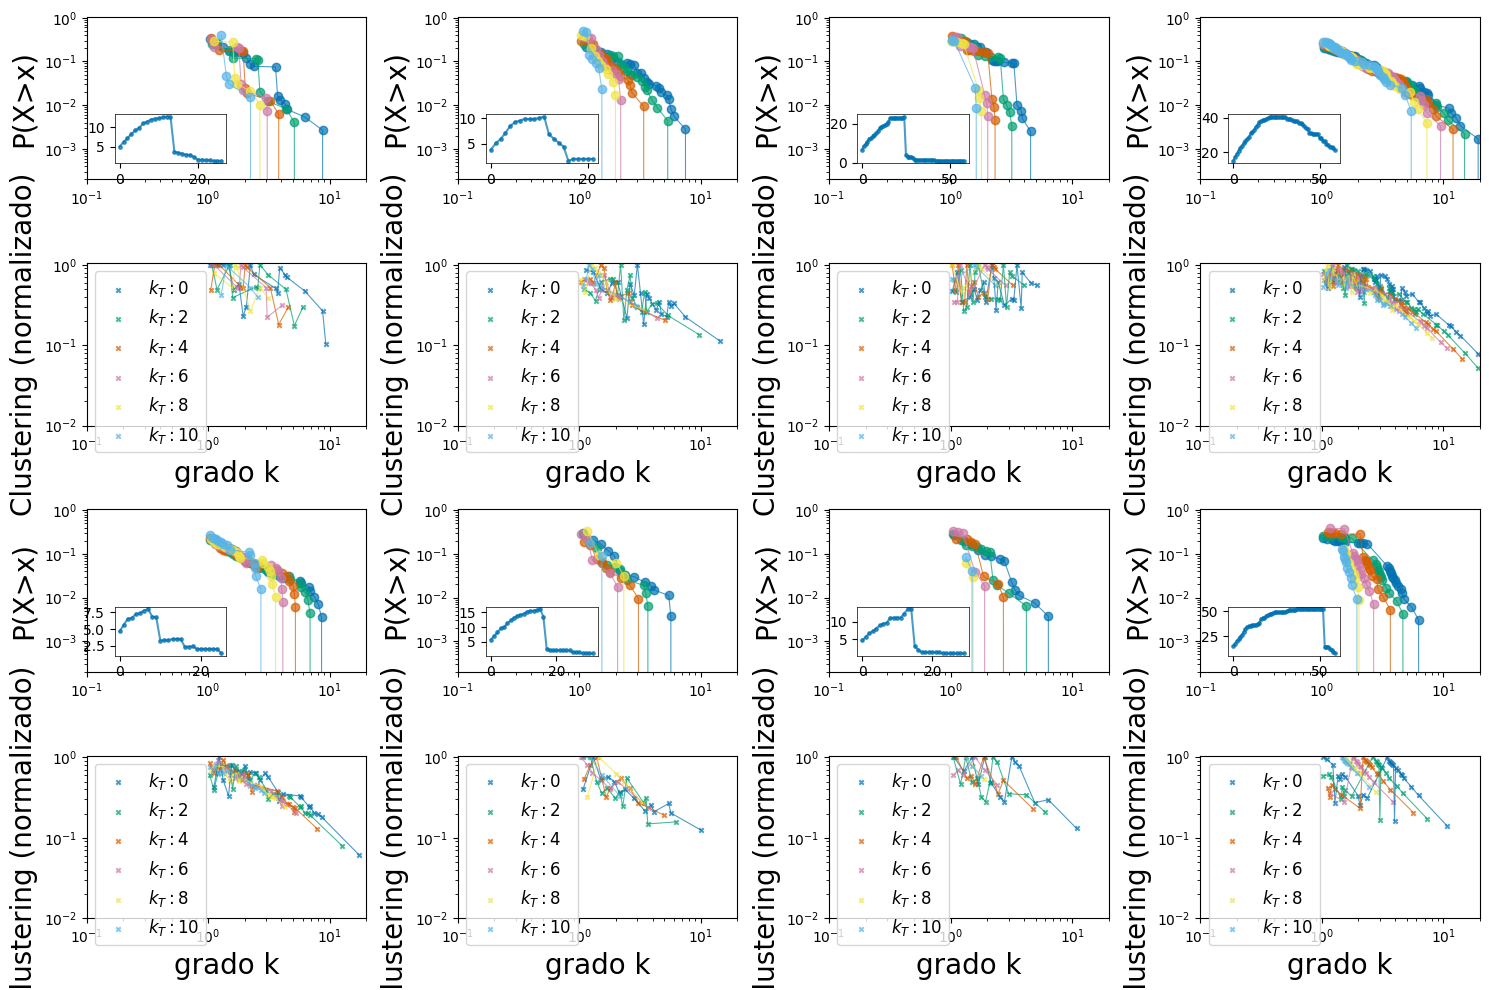

['429600',
 '429614',
 '429619',
 '429624',
 '429628',
 '429648',
 '429696',
 '429636']

In [29]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(4, 4)
fig.set_size_inches(15,10)

xlim_nat_o_e = (0.1, 20)
for i, rax in enumerate(axs[::2]):
	index = i*2
	for j, ax in enumerate(rax):
		plot_pdf_expbin(axs[index][j], arr_ccdfs_points_nat_o_e[i*len(rax)+j], arr_kt_plot_nat_o_e,
                aa=1.02, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_nat_o_e,
                marker="o", alpha=0.7, dot_size=6, line=True, normalize=False)
		#plot_pdf(axs[index][j], arr_ccdfs_points_nat_o[i*len(rax)+j], arr_kt_plot_nat_o, ylabel="P(X>x)", ylim=(0.0002, 1.05),  title=f"NAT: {otras_horas_nat[i*len(rax)+j]}")
		ax_inset = axs[index][j].inset_axes([0.1, 0.1, 0.4, 0.3])
		plot_avg_deg(ax_inset, arr_dicts_hora_nat_o[i*len(rax)+j], limit_kt_nat_o)
		plot_clust_ss_expbin(axs[index+1][j], arr_kt_plot_nat_o_e, arr_dicts_norm_int_deg_nat_o_e[i*len(rax)+j],
                     aa=1.02, xlim=xlim_nat_o_e, ylim=(0.01, 1.05),
                     alpha=0.7, marker="x", linewidth=0.8, s=10,
                     ylabel="Clustering (normalizado)", xlabel="grado k")
		

plt.tight_layout()
plt.savefig(plots_folder + "CCDF_degree_self_sim_otras_horas_exp.png")
plt.show()

["429600", "429614", "429619", "429624", "429628", "429648", "429696", "429636"]

### Redes filtradas

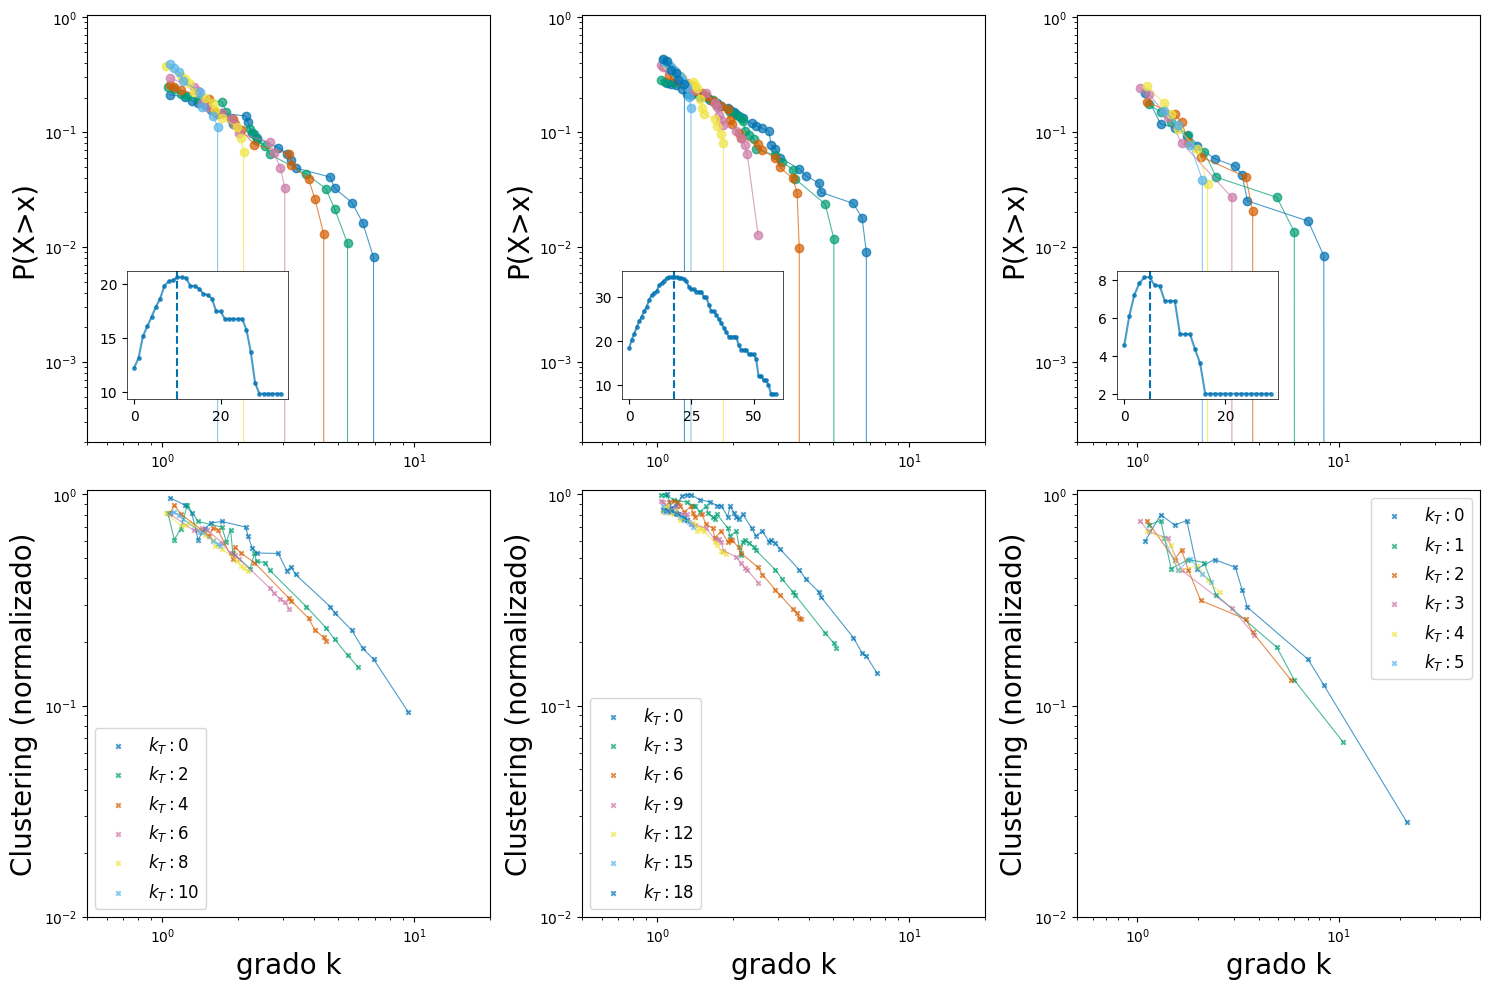

In [30]:
plt.style.use('seaborn-v0_8-colorblind')    

fig, axs = plt.subplots(2, 3)
axs = axs.flat
for ax in axs:  
	ax.set_facecolor("white")
fig.set_size_inches(15,10)

xlim_nat_f_e = (0.5, 20)
xlim_9n_f_e = (0.5, 20)
xlim_ch_f_e = (0.5, 50)

plot_pdf_expbin(axs[0], arr_ccdf_points_nat_f, arr_kt_plot_nat_f,
                aa=1.02, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_nat_f_e,
                marker="o", alpha=0.7, dot_size=6, line=True, normalize=False)
ax0_inset = axs[0].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax0_inset, dict_hora_nat_f, limit_kt_nat_f, axvline=critical_kt_nat_f)

plot_pdf_expbin(axs[1], arr_ccdf_points_9n_f, arr_kt_plot_9n_f,
                aa=1.02, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_9n_f_e,
                marker="o", alpha=0.7, dot_size=6, line=True, normalize=False)
ax1_inset = axs[1].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax1_inset, dict_hora_9n_f, limit_kt_9n_f, axvline=critical_kt_9n_f)

plot_pdf_expbin(axs[2], arr_ccdf_points_ch_f, arr_kt_plot_ch_f,
                aa=1.02, ylabel="P(X>x)", ylim=(0.0002, 1.05), xlim=xlim_ch_f_e,
                marker="o", alpha=0.7, dot_size=6, line=True, normalize=False)
ax2_inset = axs[2].inset_axes([0.1, 0.1, 0.4, 0.3])
plot_avg_deg(ax2_inset, dict_hora_ch_f, limit_kt_ch_f, axvline=critical_kt_ch_f)


plot_clust_ss_expbin(axs[3], arr_kt_plot_nat_f, dict_norm_int_deg_nat_f,
                     aa=1.02, xlim=xlim_nat_f_e, ylim=(0.01, 1.05),
                     alpha=0.7, marker="x", linewidth=0.8, s=10,
                     ylabel="Clustering (normalizado)", xlabel="grado k")

plot_clust_ss_expbin(axs[4], arr_kt_plot_9n_f, dict_norm_int_deg_9n_f,
                     aa=1.02, xlim=xlim_9n_f_e, ylim=(0.01, 1.05),
                     alpha=0.7, marker="x", linewidth=0.8, s=10,
                     ylabel="Clustering (normalizado)", xlabel="grado k")

plot_clust_ss_expbin(axs[5], arr_kt_plot_ch_f, dict_norm_int_deg_ch_f,
                     aa=1.02, xlim=xlim_ch_f_e, ylim=(0.01, 1.05),
                     alpha=0.7, marker="x", linewidth=0.8, s=10,
                     ylabel="Clustering (normalizado)", xlabel="grado k")


plt.tight_layout()
plt.savefig(plots_folder + "self_sim_exponential_filtered.png")
plt.show()

### Cálculo epsilon cuadrado por horas en redes originales

In [31]:
otras_horas_nat = [str(hor) for hor in range(429576, 429672)]

limit_kt_nat_o_e = 60
arr_kt_plot_nat_o_e = [0,2,4,6,8,10]

arr_dicts_avg_clust_nat_o_e = []
arr_dicts_norm_int_deg_nat_o_e = []
arr_ccdfs_points_nat_o_e = []
arr_dicts_hora_nat_o_e = []
arr_dicts_thres_avg_clust_nat_o_e = []
for hora in otras_horas_nat:

	dict_thres_avg_clust_nat_o_e, dict_norm_int_deg_nat_o_e = calc_self_sim(hora, MAX_UMBRAL, "nat/" + str(hour_window_nat) + '/', mode="h")
	plfit_nat_o_e, arr_pdf_points_nat_o_e, arr_ccdf_points_nat_o_e = calc_degree_distribution(hora, "nat/" + str(hour_window_nat) + '/', mode="h", arr_kt=arr_kt_plot_nat_o_e,read=False, exp=False, norm=True)
	dict_hora_nat_o_e = get_dict_hora_kt("nat", hora, hour_window=hour_window_nat, node_type="hashtag", MAX_UMBRAL=MAX_UMBRAL)

	arr_dicts_avg_clust_nat_o_e.append(dict_thres_avg_clust_nat_o_e)
	arr_dicts_norm_int_deg_nat_o_e.append(dict_norm_int_deg_nat_o_e)
	arr_ccdfs_points_nat_o_e.append(arr_ccdf_points_nat_o_e)
	arr_dicts_hora_nat_o_e.append(dict_hora_nat_o_e)

  4%|▎         | 18/500 [00:00<00:00, 2937.30it/s]


In [ ]:
import os
import numpy as np
import networkx as nx

# Usa las utilidades ya existentes en tu proyecto
# (thresh_normalization y lectura de grafos .gexf)
from utils_graphs import thresh_normalization

def _knn_by_degree(F: nx.Graph) -> dict:
    """
    Para un grafo F, calcula k_nn(k):
      - k_nn(v): grado medio de los vecinos del nodo v (nx.average_neighbor_degree)
      - k_nn(k): promedio de k_nn(v) sobre todos los nodos con grado k
    Devuelve un dict {k: k_nn(k)} con k>0.
    """
    if F.number_of_nodes() == 0:
        return {}

    # k_nn(v) por nodo (NetworkX ya lo calcula)
    ann = nx.average_neighbor_degree(F)  # dict: node -> <k_nn> de ese nodo
    deg = dict(F.degree())               # dict: node -> grado en F

    # Agrupar por grado k>0
    buckets = {}
    for v, k in deg.items():
        if k > 0 and np.isfinite(ann.get(v, np.nan)):
            buckets.setdefault(k, []).append(ann[v])

    # Promedio por cada k
    knn_k = {float(k): float(np.mean(vals)) for k, vals in buckets.items() if len(vals) > 0}
    return knn_k

def calc_knn_dict_for_hour(manifestacion: str,
                           hora_critica: str,
                           *,
                           hour_window: int = 1,
                           node_type: str = "hashtag",
                           MAX_UMBRAL: int = 200,
                           graphs_folder: str = "graphs/",
                           umbral_filt: int | None = None) -> dict:
    """
    Calcula, para una 'hora_critica', el diccionario:
        { kt (umbral) : { k : k_nn(k) } }
    usando el mismo esquema de normalización por umbral que el resto del notebook.

    - manifestacion: "nat", "9n", "ch", etc.
    - hora_critica: string tipo "429600".
    - node_type: "hashtag" | "user" | "bipartite" | "filtered" (si 'filtered', pasa umbral_filt).
    - MAX_UMBRAL: número máximo de umbrales a explorar (0..MAX_UMBRAL-1).
    """
    # Ajuste para "filtered"
    nt = node_type
    if nt == "filtered":
        nt = f"filtered/{umbral_filt}"

    # Cargar grafo de esa hora
    gexf_path = os.path.join(graphs_folder, f"nodes_{nt}", manifestacion, str(hour_window), f"{hora_critica}.gexf")
    if not os.path.exists(gexf_path):
        raise FileNotFoundError(f"No se encontró el grafo para la hora {hora_critica}: {gexf_path}")
    G = nx.read_gexf(gexf_path)

    dict_knn = {}
    for threshold in range(int(MAX_UMBRAL)):
        kt = float(threshold)
        F = thresh_normalization(G, kt)
        if F == -1:
            # Grafo vacío/inválido a partir de aquí: detenemos el barrido
            break
        dict_knn[kt] = _knn_by_degree(F)

    return dict_knn

def build_arr_dicts_knn_for_hours(manifestacion: str,
                                  horas: list[str],
                                  *,
                                  hour_window: int = 1,
                                  node_type: str = "hashtag",
                                  MAX_UMBRAL: int = 200,
                                  graphs_folder: str = "graphs/",
                                  umbral_filt: int | None = None) -> list[dict]:
    """
    Recorre 'horas' y devuelve una lista paralela:
        arr_dicts_knn = [ dict_knn_hora0, dict_knn_hora1, ... ]
    donde cada dict_knn_hora es { kt : { k : k_nn(k) } }.
    """
    out = []
    for h in horas:
        d = calc_knn_dict_for_hour(manifestacion,
                                   h,
                                   hour_window=hour_window,
                                   node_type=node_type,
                                   MAX_UMBRAL=MAX_UMBRAL,
                                   graphs_folder=graphs_folder,
                                   umbral_filt=umbral_filt)
        out.append(d)
    return out

In [42]:
# ===============================================
# Algoritmo 1 (Appendix E): cálculo de epsilon^2
# para cada hora en 'otras_horas_nat' (exp-binning)
# ===============================================

import numpy as np
import pandas as pd
from IPython.display import display

# --- Helpers: binning exponencial fijo y ϵ² ---
def _exp_bin_fixed_n(x, y, xmin, xmax, nbins):
    """
    Binning exponencial con nbins bins en [xmin, xmax].
    Devuelve un array de longitud nbins con el promedio de y por bin.
    Si un bin no tiene datos, su valor es np.nan.
    """
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = (x > 0) & np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if x.size == 0 or xmin <= 0 or xmax <= xmin:
        return np.full(nbins, np.nan)
    edges = np.geomspace(xmin, xmax, nbins + 1)
    out = np.full(nbins, np.nan)
    for i in range(nbins):
        lo, hi = edges[i], edges[i+1]
        sel = (x > lo) & (x <= hi)
        if np.any(sel):
            out[i] = y[sel].mean()
    return out

def _epsilon2_from_arr_xy_expbin(arr_xy, arr_kt_plot, nbins=20, base_index=0):
    """
    ϵ² para una lista de curvas (x,y) (mismo orden que arr_kt_plot).
    ϵ² = (1/(n+1)) * (1/nbins) * sum_{k_T} sum_i ((y_org_i - y_kT_i)/y_org_i)^2
    con bins exponenciales definidos en el rango común de X entre la curva base y cada curva.
    """
    if not arr_xy or base_index >= len(arr_xy):
        return np.nan

    x_org, y_org = arr_xy[base_index]
    x_org = np.asarray(x_org, float); y_org = np.asarray(y_org, float)
    n_plus_1 = len(arr_kt_plot)
    total = 0.0

    for idx in range(len(arr_xy)):
        x_k, y_k = arr_xy[idx]
        x_k = np.asarray(x_k, float); y_k = np.asarray(y_k, float)

        v_org = np.isfinite(x_org) & (x_org > 0)
        v_k   = np.isfinite(x_k) & (x_k > 0)
        if not (np.any(v_org) and np.any(v_k)):
            continue

        xmin = max(np.nanmin(x_org[v_org]), np.nanmin(x_k[v_k]))
        xmax = min(np.nanmax(x_org[v_org]), np.nanmax(x_k[v_k]))
        if not np.isfinite(xmin) or not np.isfinite(xmax) or xmin <= 0 or xmax <= xmin:
            continue

        yb_org = _exp_bin_fixed_n(x_org, y_org, xmin, xmax, nbins)
        yb_k   = _exp_bin_fixed_n(x_k, y_k, xmin, xmax, nbins)

        m = np.isfinite(yb_org) & np.isfinite(yb_k) & (yb_org != 0)
        if not np.any(m):
            continue

        dif2 = ((yb_org[m] - yb_k[m]) / yb_org[m]) ** 2

        # Promedio sobre nbins (rellenando con 0 los bins sin datos válidos)
        accum = np.zeros(nbins, dtype=float)
        idx_m = np.where(m)[0]
        for j, pos in enumerate(idx_m):
            accum[pos] = dif2[j]
        total += accum.sum() / nbins

    return total / max(n_plus_1, 1)

def _epsilon2_from_clust_dict_expbin(dict_norm_int_deg, arr_kt_plot, nbins=20, base_index=0):
    """
    ϵ² para un diccionario: kt -> {grado: valor} (p.ej., clustering normalizado).
    Convierte a lista de (x,y) en el orden de arr_kt_plot y llama a la rutina anterior.
    """
    arr_xy = []
    for kt in arr_kt_plot:
        d = dict_norm_int_deg.get(kt, {})
        if not d:
            arr_xy.append((np.array([], float), np.array([], float)))
        else:
            xs = np.array(list(d.keys()), float)
            ys = np.array(list(d.values()), float)
            arr_xy.append((xs, ys))
    return _epsilon2_from_arr_xy_expbin(arr_xy, arr_kt_plot, nbins=nbins, base_index=base_index)


def epsilon2_from_knn_dict_expbin(dict_knn, arr_kt_plot, nbins=20, base_index=0):
    """
    Calcula ϵ² para k_nn(k) usando binning exponencial y el Algoritmo 1.
    Parámetros:
      - dict_knn: dict con estructura {kt: {k: k_nn(k)}}
      - arr_kt_plot: lista con los k_T en el orden en que se comparan/grafica
      - nbins: número de bins exponenciales (paper sugiere 20)
      - base_index: índice dentro de arr_kt_plot que se toma como "original"
                    (si quieres que sea k_T=2, usa base_index = arr_kt_plot.index(2))
    Devuelve:
      - escalar con el valor de ϵ².
    """
    arr_xy = []
    for kt in arr_kt_plot:
        d = dict_knn.get(kt, {})
        if d:
            xs = np.array(list(d.keys()), float)
            ys = np.array(list(d.values()), float)
        else:
            xs = np.array([], float); ys = np.array([], float)
        arr_xy.append((xs, ys))
    return _epsilon2_from_arr_xy_expbin(arr_xy, arr_kt_plot, nbins=nbins, base_index=base_index)


# --- Cálculo de ϵ² por hora ---
# Parámetros del algoritmo (paper sugiere nbins=20; base kt puede ser 2)
nbins = 1000
base_kt_pref = 0  # si no está en arr_kt_plot_nat_o_e, se usará el primer elemento
base_index = 0
if 'arr_kt_plot_nat_o_e' in globals() and base_kt_pref in arr_kt_plot_nat_o_e:
    base_index = arr_kt_plot_nat_o_e.index(base_kt_pref)

# Chequeo rápido de variables necesarias
_needed = ['otras_horas_nat', 'arr_ccdfs_points_nat_o_e', 'arr_dicts_norm_int_deg_nat_o_e', 'arr_kt_plot_nat_o_e']
_missing = [v for v in _needed if v not in globals()]
if _missing:
    raise RuntimeError(f"Faltan variables previas: {_missing}. Ejecuta antes las celdas que construyen los datos expbin.")
arr_dicts_knn_nat_o_e = build_arr_dicts_knn_for_hours(
     manifestacion="nat",
     horas=otras_horas_nat,
     hour_window=hour_window_nat,
     node_type="hashtag",     # o "filtered" si procede, con umbral_filt=...
     MAX_UMBRAL=MAX_UMBRAL,
     graphs_folder="graphs/",
     umbral_filt=None
)

eps_rows = []
for i, hora in enumerate(otras_horas_nat):
    # ϵ² sobre CCDF (lo que entra a plot_pdf_expbin)
    try:
        arr_xy = arr_ccdfs_points_nat_o_e[i]  # lista de (x,y) por k_T
        eps_ccdf = _epsilon2_from_arr_xy_expbin(arr_xy, arr_kt_plot_nat_o_e, nbins=nbins, base_index=base_index)
    except Exception:
        eps_ccdf = np.nan

    # ϵ² sobre clustering normalizado (lo que entra a plot_clust_ss_expbin)
    try:
        dict_k = arr_dicts_norm_int_deg_nat_o_e[i]  # dict: kt -> {grado: valor}
        eps_c = _epsilon2_from_clust_dict_expbin(dict_k, arr_kt_plot_nat_o_e, nbins=nbins, base_index=base_index)
    except Exception:
        eps_c = np.nan
    try:
        eps_knn = epsilon2_from_knn_dict_expbin(arr_dicts_knn_nat_o_e[i],arr_kt_plot_nat_o_e,nbins=nbins,base_index=base_index)
    except Exception:
        eps_knn = np.nan
    eps_rows.append({"hora": hora, "epsilon2_ccdf": float(eps_ccdf), "epsilon2_c": float(eps_c), "epsilon_knn": float(eps_knn), "epsilon_max": max(float(eps_ccdf), float(eps_c), float(eps_knn))})

eps_df = pd.DataFrame(eps_rows).set_index("hora")
print(f"ϵ² (nbins={nbins}, base k_T={arr_kt_plot_nat_o_e[base_index] if len(arr_kt_plot_nat_o_e)>0 else 'N/A'})")
display(eps_df)

# Guardado opcional
try:
    eps_df.to_csv(plots_folder + "epsilon2_otras_horas_nat_expbin.csv")
except Exception as _e:
    print("Aviso: no se pudo guardar el CSV con epsilon^2.", _e)


ϵ² (nbins=1000, base k_T=0)


,epsilon2_ccdf,epsilon2_c,epsilon_knn,epsilon_max
hora,,,,
429576,0.000000,0.000000,0.004592,0.004592
429577,0.000000,0.000000,0.003121,0.003121
429578,0.000000,0.000000,0.003924,0.003924
429579,0.000000,0.000000,0.000444,0.000444
429580,0.000167,0.000012,0.001512,0.001512
...,...,...,...,...
429667,0.000033,0.000150,0.001820,0.001820
429668,0.000037,0.000018,0.000793,0.000793
429669,0.000030,0.000000,0.001337,0.001337


Figura guardada en: plots/latex/epsilon2_vs_hora_nat_expbin.png


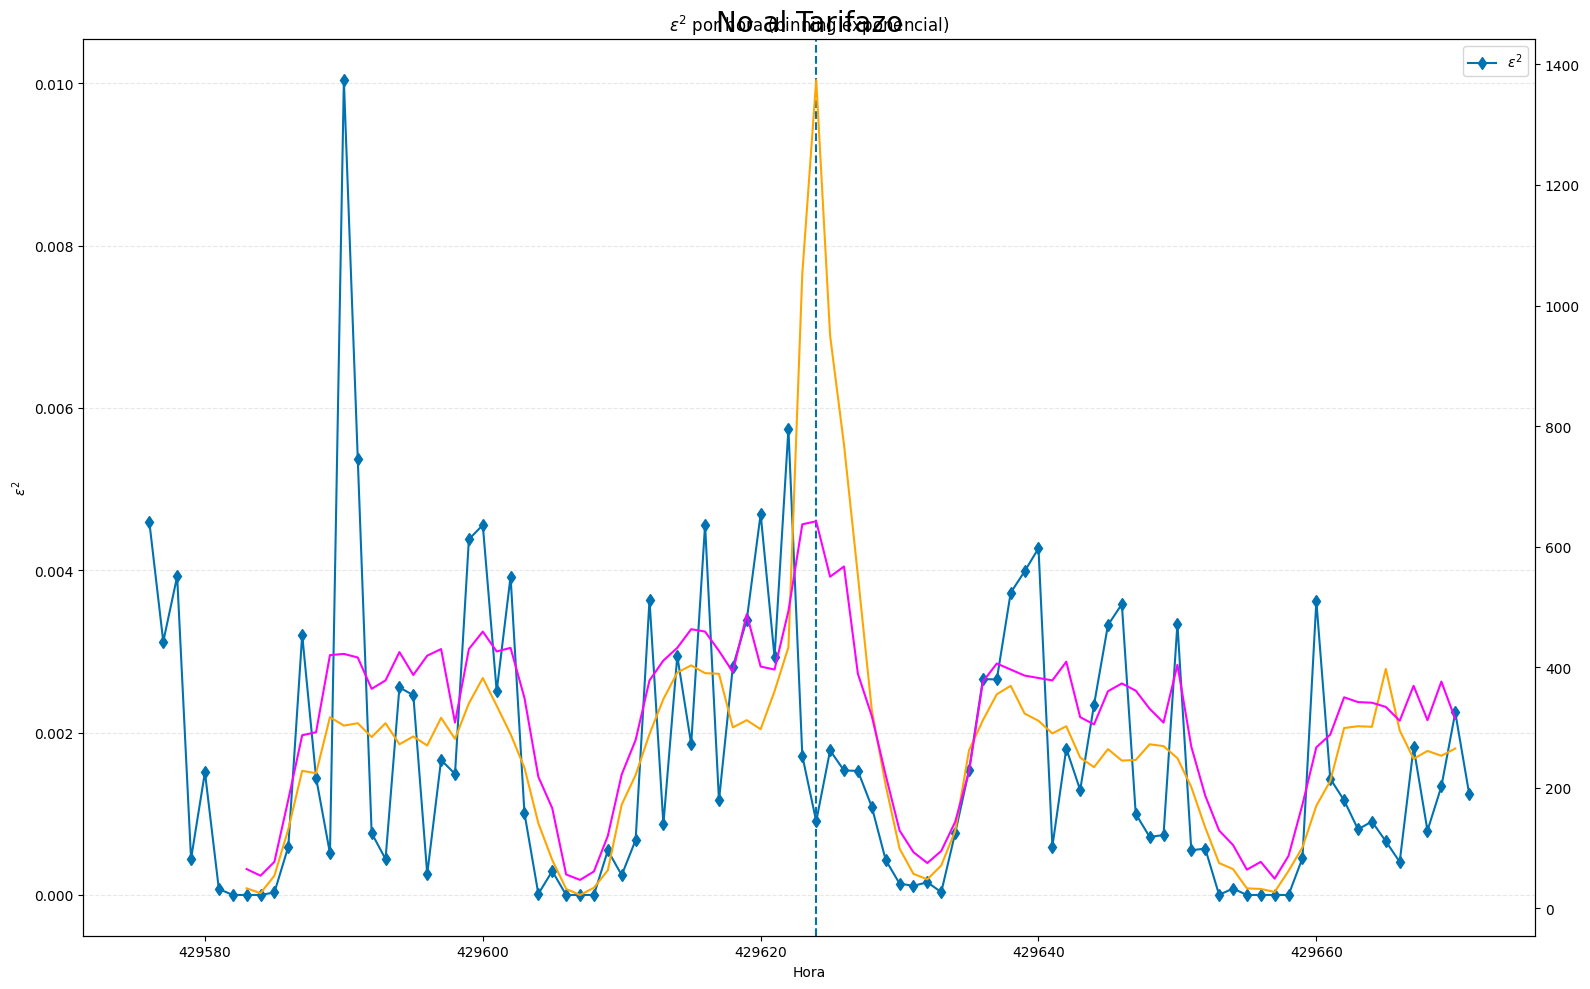

In [43]:
# ================================
# Plot de epsilon^2 vs horas (CCDF y Clustering)
# ================================
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-colorblind')

# Comprobación básica
if 'eps_df' not in globals():
    raise RuntimeError("Primero ejecuta la celda que calcula eps_df (epsilon^2 por hora).")

# Ordenar por el orden original de 'otras_horas_nat' si está disponible
if 'otras_horas_nat' in globals():
    horas = list(otras_horas_nat)
    df_plot = eps_df.reindex(horas)
else:
    df_plot = eps_df.copy()
    horas = list(df_plot.index)

fig, ax = plt.subplots(figsize=(16, 10))
df_nat = read_data("nat", datasets_folder=datasets_folder)

hour_nat = np.sort(df_nat["hour"].unique())[::hour_window_nat]


num_users_nat, num_hashtags_nat = get_num_users_hashtags(df_nat, hour_window=hour_window_nat)
ax1 = ax.twinx()
plot_num_users_hashtags(ax1, hour_nat, hour_window_nat, num_users_nat, num_hashtags_nat, title="No al Tarifazo", inicio=52, final=140, legend=False)

horas = [int(h) for h in horas]
#ax.plot(horas, df_plot['epsilon2_ccdf'].values, marker='o', label=r'$\epsilon^2$ CCDF')
#ax.plot(horas, df_plot['epsilon2_c'].values,     marker='s', label=r'$\epsilon^2$ clustering')
#ax.plot(horas, df_plot['epsilon_knn'].values,     marker='d', label=r'$\epsilon^2$ knn')
ax.plot(horas, df_plot['epsilon_max'].values,     marker='d', label=r'$\epsilon^2$')
ax.axvline(429624, ls="--")

ax.set_xlabel('Hora')
ax.set_ylabel(r'$\epsilon^2$')
ax.set_title(r'$\epsilon^2$ por hora (binning exponencial)')
ax.grid(True, which='both', axis='y', linestyle='--', alpha=0.3)
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Guardado opcional
try:
    fname = plots_folder + "epsilon2_vs_hora_nat_expbin.png"
    plt.savefig(fname, dpi=150)
    print("Figura guardada en:", fname)
except Exception as e:
    print("No se pudo guardar la figura:", e)

plt.show()
